In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [14]:
pip install rpy2

Note: you may need to restart the kernel to use updated packages.


# Trying to import the csv

In [2]:
# Load your data
imfeatures = pd.read_csv("imagingFeatures.csv")
imfeatures = imfeatures.dropna()

# Load the second dataset
clinical_data = pd.read_csv("clinicalData_clean.csv")
print(clinical_data['Mol Subtype'])
#clinical_data = clinical_data.dropna() # It's good practice to handle NaNs in both dataframes

# Merge the two dataframes using an inner join on 'Patient_ID'
# The .merge() method takes the other DataFrame as the first argument,
# and 'on' is used to specify the common column for merging.
merged = imfeatures.merge(clinical_data, on='Patient ID', how='inner')
#merged['Mol Subtype']
clinical_data['Mol Subtype'].dtype

0      2
1      3
2      0
3      0
4      1
      ..
917    0
918    0
919    0
920    0
921    0
Name: Mol Subtype, Length: 922, dtype: int64


dtype('int64')

In [3]:
# Step 1: Drop non-feature columns (like ID)
imfeatures = imfeatures.drop(columns=["Unnamed: 0", "Patient ID"], errors="ignore")

imfeatures

,"F1_DT_POSTCON (T11=0.05,T12=0.5)","F1_DT_POSTCON (T11=0.05,T12=0.1)","F1_DT_POSTCON (T11=0.02,T12=0.5)","F1_DT_POSTCON (T11=0.02,T12=0.8)","F1_DT_POSTCON (T11=0.05,T12=0.8)","F1_DT_POSTCON (T11=0.1,T12=0.5)","F1_DT_POSTCON (T11=0.1,T12=0.8)","F1_DT_POSTCON (T11=0.2,T12=0.5)","F1_DT_POSTCON (T11=0.2,T12=0.8)","F1_DT_T1NFS (T11=0.05,T12=0.5)",...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,1.000000,0.120721,0.530395,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,...,3.380663,-0.025575,0.422391,0.171959,0.960359,0.996829,14.517894,20.347506,1.625870,11.406955
1,1.000000,0.129546,0.485217,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.432916,...,3.444474,-0.036063,0.505652,0.177087,0.959067,0.996363,47.297950,83.909561,0.251498,5.659428
2,0.174775,0.062051,0.069910,0.132265,0.330662,0.349550,0.661324,0.699100,1.00000,0.185670,...,3.478455,-0.043730,0.546674,0.170507,0.957527,0.995981,114.171582,129.252342,1.928743,11.554948
4,0.289669,0.052031,0.115868,0.378575,0.839984,0.579338,1.000000,0.958287,1.00000,0.392859,...,4.009938,-0.049294,0.603426,0.117966,0.930624,0.989135,34.406635,26.951415,0.985464,4.331451
5,0.297156,0.074791,0.118862,0.253568,0.633921,0.594311,1.000000,1.000000,1.00000,0.445015,...,3.546936,-0.045549,0.561651,0.166956,0.954940,0.995613,277.427199,252.568247,1.014581,5.344516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,0.091844,0.050240,0.036738,0.103783,0.259457,0.183688,0.518915,0.367377,0.90289,0.125807,...,3.948053,-0.090354,0.754825,0.135670,0.935277,0.989856,591.035965,397.002913,0.449477,2.857014
917,0.587345,0.115746,0.234938,0.479802,1.000000,1.000000,1.000000,1.000000,1.00000,0.336273,...,3.116735,-0.050326,0.565456,0.223324,0.970250,0.997982,30.665570,65.018278,1.563114,12.928674
919,0.742209,0.058729,0.296884,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.609958,...,3.369220,-0.050465,0.572790,0.178169,0.961318,0.996820,17.724748,18.299933,2.282520,13.460166
920,0.381016,0.089668,0.152406,0.256513,0.641281,0.768252,1.000000,1.000000,1.00000,0.313589,...,3.191276,-0.103623,0.750372,0.218098,0.968191,0.997618,149.643082,157.235282,1.318530,9.176372


In [4]:
# Step 2: Standardize all features (z-score)
scaler = StandardScaler()
standardized_data = scaler.fit_transform(imfeatures)

In [5]:
# Step 3: Convert back to DataFrame with original column names
standardized_imfeatures = pd.DataFrame(standardized_data, columns=imfeatures.columns)

In [6]:
# Optional: Save the standardized data
standardized_imfeatures.to_csv("imagingFeatures_standardized_all.csv", index=False)

In [7]:
standardized_imfeatures

,"F1_DT_POSTCON (T11=0.05,T12=0.5)","F1_DT_POSTCON (T11=0.05,T12=0.1)","F1_DT_POSTCON (T11=0.02,T12=0.5)","F1_DT_POSTCON (T11=0.02,T12=0.8)","F1_DT_POSTCON (T11=0.05,T12=0.8)","F1_DT_POSTCON (T11=0.1,T12=0.5)","F1_DT_POSTCON (T11=0.1,T12=0.8)","F1_DT_POSTCON (T11=0.2,T12=0.5)","F1_DT_POSTCON (T11=0.2,T12=0.8)","F1_DT_T1NFS (T11=0.05,T12=0.5)",...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,1.898017,0.791441,1.377394,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,2.469875,...,-0.127296,1.125159,-1.327434,-0.233161,0.221347,0.450227,-0.836444,-0.920307,0.036994,-0.084546
1,1.898017,0.955974,1.182981,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.198198,...,0.047559,0.626576,-0.483970,-0.133400,0.128963,0.288776,-0.614330,-0.449281,-1.266008,-0.084569
2,-0.791197,-0.302303,-0.604213,-0.824636,-0.982887,-0.921828,-0.703374,-0.681431,0.342477,-0.792241,...,0.140673,0.262104,-0.068406,-0.261412,0.018903,0.156444,-0.161201,-0.113269,0.324139,-0.084546
3,-0.416785,-0.489109,-0.406444,-0.094890,0.586843,-0.159588,0.672063,0.505528,0.342477,0.037734,...,1.597036,-0.002384,0.506513,-1.283458,-1.904114,-2.215655,-0.701680,-0.871368,-0.570157,-0.084575
4,-0.392387,-0.064796,-0.393557,-0.465249,-0.048244,-0.109918,0.672063,0.696554,0.342477,0.246665,...,0.328323,0.175663,0.083314,-0.330482,-0.166040,0.028843,0.945002,0.800562,-0.542551,-0.084571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,-1.061449,-0.522488,-0.746964,-0.909019,-1.202340,-1.472015,-1.281730,-2.200571,-0.499945,-1.032046,...,1.427459,-1.954300,2.040245,-0.939074,-1.571518,-1.965662,3.069982,1.870894,-1.078309,-0.084581
857,0.553270,0.698694,0.105952,0.205013,1.080013,1.235811,0.672063,0.696554,0.342477,-0.188943,...,-0.850507,-0.051451,0.121860,0.766020,0.928356,0.849904,-0.727029,-0.589274,-0.022503,-0.084540
858,1.057936,-0.364225,0.372523,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.907408,...,-0.158651,-0.058056,0.196165,-0.112360,0.289898,0.447085,-0.814714,-0.935480,0.659545,-0.084538
859,-0.119106,0.212540,-0.249206,-0.456526,-0.025557,0.467067,0.672063,0.696554,0.342477,-0.279812,...,-0.646252,-2.585089,1.995127,0.664356,0.781141,0.723552,0.079150,0.094099,-0.254386,-0.084555


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load the standardized data
df = pd.read_csv("imagingFeatures_standardized_all.csv")
df

,"F1_DT_POSTCON (T11=0.05,T12=0.5)","F1_DT_POSTCON (T11=0.05,T12=0.1)","F1_DT_POSTCON (T11=0.02,T12=0.5)","F1_DT_POSTCON (T11=0.02,T12=0.8)","F1_DT_POSTCON (T11=0.05,T12=0.8)","F1_DT_POSTCON (T11=0.1,T12=0.5)","F1_DT_POSTCON (T11=0.1,T12=0.8)","F1_DT_POSTCON (T11=0.2,T12=0.5)","F1_DT_POSTCON (T11=0.2,T12=0.8)","F1_DT_T1NFS (T11=0.05,T12=0.5)",...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,1.898017,0.791441,1.377394,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,2.469875,...,-0.127296,1.125159,-1.327434,-0.233161,0.221347,0.450227,-0.836444,-0.920307,0.036994,-0.084546
1,1.898017,0.955974,1.182981,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.198198,...,0.047559,0.626576,-0.483970,-0.133400,0.128963,0.288776,-0.614330,-0.449281,-1.266008,-0.084569
2,-0.791197,-0.302303,-0.604213,-0.824636,-0.982887,-0.921828,-0.703374,-0.681431,0.342477,-0.792241,...,0.140673,0.262104,-0.068406,-0.261412,0.018903,0.156444,-0.161201,-0.113269,0.324139,-0.084546
3,-0.416785,-0.489109,-0.406444,-0.094890,0.586843,-0.159588,0.672063,0.505528,0.342477,0.037734,...,1.597036,-0.002384,0.506513,-1.283458,-1.904114,-2.215655,-0.701680,-0.871368,-0.570157,-0.084575
4,-0.392387,-0.064796,-0.393557,-0.465249,-0.048244,-0.109918,0.672063,0.696554,0.342477,0.246665,...,0.328323,0.175663,0.083314,-0.330482,-0.166040,0.028843,0.945002,0.800562,-0.542551,-0.084571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,-1.061449,-0.522488,-0.746964,-0.909019,-1.202340,-1.472015,-1.281730,-2.200571,-0.499945,-1.032046,...,1.427459,-1.954300,2.040245,-0.939074,-1.571518,-1.965662,3.069982,1.870894,-1.078309,-0.084581
857,0.553270,0.698694,0.105952,0.205013,1.080013,1.235811,0.672063,0.696554,0.342477,-0.188943,...,-0.850507,-0.051451,0.121860,0.766020,0.928356,0.849904,-0.727029,-0.589274,-0.022503,-0.084540
858,1.057936,-0.364225,0.372523,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.907408,...,-0.158651,-0.058056,0.196165,-0.112360,0.289898,0.447085,-0.814714,-0.935480,0.659545,-0.084538
859,-0.119106,0.212540,-0.249206,-0.456526,-0.025557,0.467067,0.672063,0.696554,0.342477,-0.279812,...,-0.646252,-2.585089,1.995127,0.664356,0.781141,0.723552,0.079150,0.094099,-0.254386,-0.084555


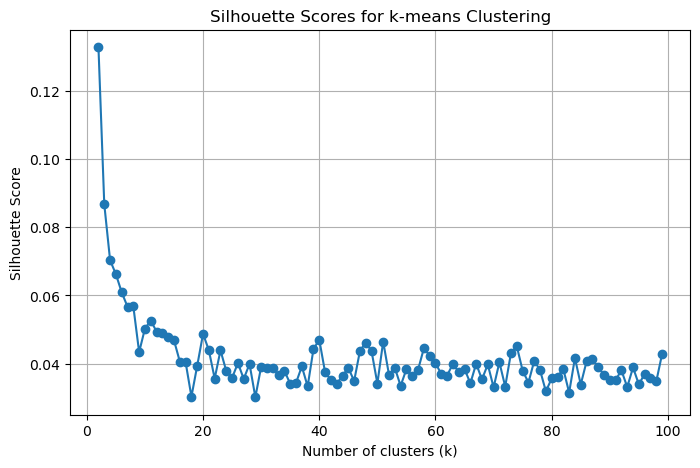

In [9]:
# Try k from 2 to 100
silhouette_scores = []
cluster_results = {}

for k in range(2, 100):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df)
    silhouette = silhouette_score(df, labels)
    silhouette_scores.append(silhouette)
    cluster_results[k] = labels

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 100), silhouette_scores, marker='o')
plt.title("Silhouette Scores for k-means Clustering")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [10]:
# Perform K-Means clustering on the standardized imaging data (full dimensionality)
best_k = 13 # Or your chosen k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10) # n_init is important for robust results
labels = kmeans.fit_predict(standardized_imfeatures)

# Add cluster labels to the original merged DataFrame
merged['Cluster'] = labels

# Create a table to see results (cross-tabulation of cluster vs. molecular subtype)
# Ensure 'Subtype' column exists in your clinical_data and thus in 'merged'
print("--- K-Means Cluster Distribution by Molecular Subtype ---")

# If you want a confusion matrix, you need both a predicted and a true label.
# Here, 'cluster' is the predicted group from KMeans, and 'Mol Subtype' is the true label.
# The crosstab below is correct for showing overlap between clusters and true subtypes.
table = pd.crosstab(merged['Cluster'], merged['Mol Subtype'])
print(table)



--- K-Means Cluster Distribution by Molecular Subtype ---
Mol Subtype   0   1   2   3
Cluster                    
0            91  11   6  38
1            40   8   6  15
2            83   8  11  16
3             6   3   4   3
4            46   6   0   3
5            54  10   4  13
6            23   7   5   6
7            43  18   4  12
8             0   0   0   1
9            34   7   3   7
10           44  12   5  14
11           44   8   1  14
12           37   2   9  16


In [11]:
# Optional: Add percentages to the table for better interpretation
print("\n--- K-Means Cluster Distribution by Molecular Subtype (Percentages within each cluster) ---")
table_percent = table.apply(lambda r: r/r.sum(), axis=1) * 100
pd.set_option('display.max_rows', None)
print(table_percent.round(2))
pd.reset_option('all')


--- K-Means Cluster Distribution by Molecular Subtype (Percentages within each cluster) ---
Mol Subtype      0      1      2       3
Cluster                                 
0            62.33   7.53   4.11   26.03
1            57.97  11.59   8.70   21.74
2            70.34   6.78   9.32   13.56
3            37.50  18.75  25.00   18.75
4            83.64  10.91   0.00    5.45
5            66.67  12.35   4.94   16.05
6            56.10  17.07  12.20   14.63
7            55.84  23.38   5.19   15.58
8             0.00   0.00   0.00  100.00
9            66.67  13.73   5.88   13.73
10           58.67  16.00   6.67   18.67
11           65.67  11.94   1.49   20.90
12           57.81   3.12  14.06   25.00


C:\Users\k8pod\AppData\Local\Temp\ipykernel_10668\1822477023.py:6: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\k8pod\AppData\Local\Temp\ipykernel_10668\1822477023.py:6: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [ ]:
# mclust, subspace clustering, projection clustering, bootstrap, correlation ... 
#more high dimensional clustering techniques 
# NOT WORKING

from mclustpy.mclust import Mclust
import numpy as np

import rpy2.robjects as robjects
#print(robjects.r('version'))

mclust_model = Mclust(standardized_imfeatures)
print("Optimal number of clusters:", mclust_model.n_clusters)
# Cluster assignments
print("Cluster labels:", mclust_model.labels_)

# Probabilities of each point belonging to each cluster
print("Cluster probabilities:", mclust_model.probabilities_)

# Model parameters
print("Means:", mclust_model.means_)
print("Covariances:", mclust_model.covariances_)



ModuleNotFoundError: No module named 'mclustpy'

In [5]:
import sys
print(sys.executable)

c:\Users\k8pod\anaconda3\python.exe


In [3]:
import rpy2.robjects as robjects
print(robjects.r('version'))

ModuleNotFoundError: No module named 'rpy2'